## Sampling distribution

Sampling distribution refers to the distribution of a statistic, such as the sample mean, calculated from multiple random samples drawn from a population. It helps estimate population parameters, test hypotheses, and analyze variability.

**Procedure**:
1. **Define Population**: Choose or generate the population data, like the `total_bill` column in the tips dataset.
2. **Draw Samples**: Randomly extract multiple samples of fixed size (e.g., 30) from the population.
3. **Compute Statistics**: Calculate the desired statistic (e.g., sample mean) for each sample.
4. **Visualize**: Plot a histogram or KDE of the sample statistics to observe the distribution.

The sampling distribution of the sample mean approximates a **normal distribution** as per the Central Limit Theorem. It centers around the population mean, with a reduced spread (Standard Error), reflecting increased precision as sample size grows. Including population metrics like the mean and standard deviation in the visualization provides insights into the relationship between population and sample statistics.

A sampling distribution for the tips dataset, treating it as the population is plotted. Samples are drawn randomly to calculate sample statistics (mean for total_bill), and visualize their distribution:

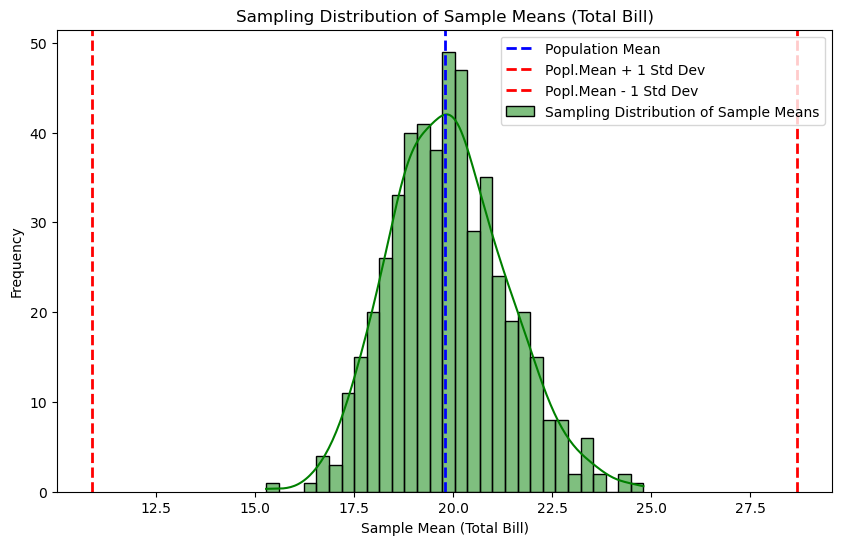

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load tips dataset
tips = sns.load_dataset('tips')

# Example data from the tips dataset (considered as population)
data = {
    'total_bill': tips.total_bill,
    'tip': tips.tip
}
df = pd.DataFrame(data)

# Treat 'total_bill' as the population
population = df['total_bill']

# Population mean and standard deviation
population_mean = np.mean(population)
population_std = np.std(population)

# Step 1: Draw random samples and compute sample means
sample_size = 30  # Size of each sample
num_samples = 500  # Number of samples to draw
sample_means = []  # To store sample means

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)  # Random sampling
    sample_means.append(np.mean(sample))

# Step 2: Visualize the sampling distribution
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, color='green', bins=30, label='Sampling Distribution of Sample Means')

# Add vertical lines for population mean and standard deviation
plt.axvline(population_mean, color='blue', linestyle='--', linewidth=2, label='Population Mean')
plt.axvline(population_mean + population_std, color='red', linestyle='--', linewidth=2, label='Popl.Mean + 1 Std Dev')
plt.axvline(population_mean - population_std, color='red', linestyle='--', linewidth=2, label='Popl.Mean - 1 Std Dev')

# Add labels and title
plt.title('Sampling Distribution of Sample Means (Total Bill)')
plt.xlabel('Sample Mean (Total Bill)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Central limit theorem
The Central Limit Theorem is a cornerstone of statistics that explains why sampling distributions are essential for inferential statistics. It states that when a sufficiently large number of random samples are drawn from any population, the sampling distribution of the sample mean tends to follow a normal distribution—regardless of the population's original distribution. This property enables statisticians to make inferences about populations, even when they are not normally distributed.
What Does the CLT Tell Us?
When repeatedly sampling from a population:
The sampling distribution of the sample mean approaches a normal distribution as the sample size increases.
The mean of the sampling distribution equals the population mean $$ \mu_{\bar{x}} = \mu $$.
The spread of the sampling distribution, called the Standard Error (SE), decreases with larger sample sizes and is calculated as:
 $$ SE = \frac{\sigma}{\sqrt{n}} $$

 where $\sigma$ is the population standard deviation, and n is the sample size.

**Conditions for CLT to Hold:**
* Sample Size: The sample size n must be sufficiently large. Typically, $$n \geq 30$$ is considered enough for most populations.
* Independence: Samples must be independent of one another.
* Random Sampling: The samples must be randomly selected from the population.


### Visualizing central limit theorem
The CLT can be demonstrated using sampling distributions. For example, if we take the tips dataset and repeatedly draw random samples of size 30 from the total_bill column (population):

Population Mean: 19.79
Population Standard Deviation: 8.88
Sampling Distribution Mean: 19.81
Sampling Distribution Standard Deviation (Standard Error): 1.55


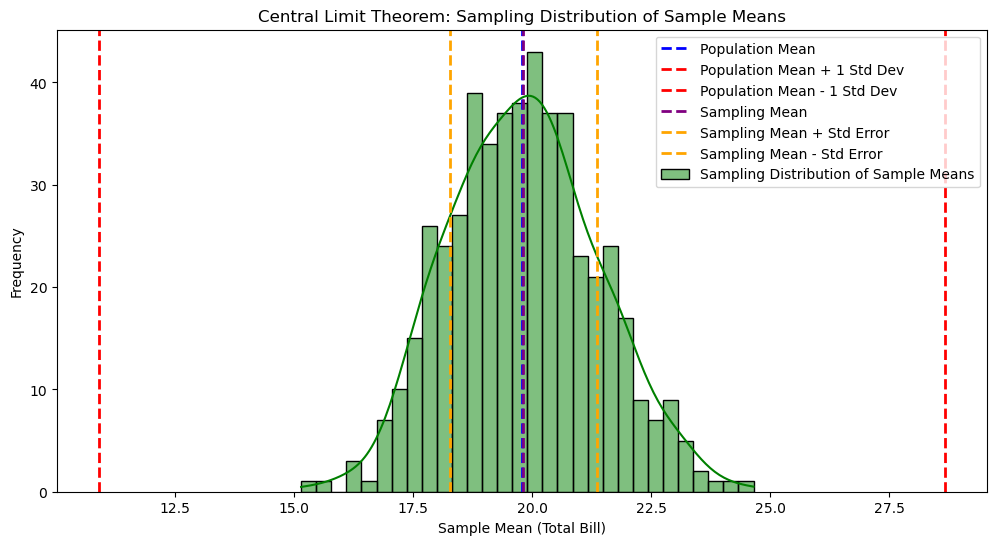

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the tips dataset
tips = sns.load_dataset('tips')

# Extract the 'total_bill' column and treat it as the population
population = tips['total_bill']

# Calculate population mean and standard deviation
population_mean = np.mean(population)
population_std = np.std(population)

print(f"Population Mean: {population_mean:.2f}")
print(f"Population Standard Deviation: {population_std:.2f}")

# Step 1: Draw random samples and compute sample means
sample_size = 30  # Size of each sample
num_samples = 500  # Number of samples to draw
sample_means = []  # To store sample means

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)  # Random sampling
    sample_means.append(np.mean(sample))

# Step 2: Calculate sampling distribution metrics
sampling_mean = np.mean(sample_means)  # Mean of the sampling distribution
sampling_std = np.std(sample_means)    # Standard deviation of the sampling distribution

print(f"Sampling Distribution Mean: {sampling_mean:.2f}")
print(f"Sampling Distribution Standard Deviation (Standard Error): {sampling_std:.2f}")

# Step 3: Visualize the sampling distribution
plt.figure(figsize=(12, 6))
sns.histplot(sample_means, kde=True, color='green', bins=30, label='Sampling Distribution of Sample Means')

# Add vertical lines for population mean and standard deviation
plt.axvline(population_mean, color='blue', linestyle='--', linewidth=2, label='Population Mean')
plt.axvline(population_mean + population_std, color='red', linestyle='--', linewidth=2, label='Population Mean + 1 Std Dev')
plt.axvline(population_mean - population_std, color='red', linestyle='--', linewidth=2, label='Population Mean - 1 Std Dev')

# Add vertical lines for sampling mean and standard error
plt.axvline(sampling_mean, color='purple', linestyle='--', linewidth=2, label='Sampling Mean')
plt.axvline(sampling_mean + sampling_std, color='orange', linestyle='--', linewidth=2, label='Sampling Mean + Std Error')
plt.axvline(sampling_mean - sampling_std, color='orange', linestyle='--', linewidth=2, label='Sampling Mean - Std Error')

# Add labels and title
plt.title('Central Limit Theorem: Sampling Distribution of Sample Means')
plt.xlabel('Sample Mean (Total Bill)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Sampling distribution for proportions

Sampling distribution is the probability distribution of a statistic obtained from a large number of samples drawn from a population.

- The **sample proportion** refers to the proportion of a certain characteristic in a random sample.
- For example, if we are analyzing the `sex` column of the tips dataset, the sample proportion could represent the proportion of males or females in different samples.

Key properties:
1. The **mean** of the sampling distribution of sample proportions equals the true population proportion p.
   $$
   \mu_{\hat{p}} = p
   $$
2. The **standard deviation** of the sampling distribution (also known as the standard error) is given by:
   $$
   \sigma_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}}
   $$
   where n is the sample size.
3. As the sample size increases, the sampling distribution becomes approximately normal, irrespective of the population’s distribution. This is a result of the **Central Limit Theorem (CLT)**.

### **Central Limit Theorem (CLT) for Sample Proportions**
The Central Limit Theorem states:
- For a sufficiently large sample size, the sampling distribution of the sample proportion \(\hat{p}\) will be approximately normal, regardless of the population's actual distribution.

**Conditions for CLT to hold:**
- The sample size \(n\) must be large enough such that:
  $$
  n \cdot p \geq 10 \quad \text{and} \quad n \cdot (1-p) \geq 10
  $$
  where \(p\) is the population proportion.

### **Example Using the Tips Dataset**

We will demonstrate the CLT using the `sex` column of the **tips dataset**, which contains data about restaurant tips, including the gender of the customer (`Male` or `Female`). The goal is to show that the sample proportions of males approximate a normal distribution when sampled repeatedly.

In [ ]:
# Step 1: Load and Explore the Dataset
import seaborn as sns
import numpy as np

# Load the tips dataset
tips = sns.load_dataset('tips')

# Check the `sex` column
print(tips['sex'].value_counts(normalize=True))

sex
Male      0.643443
Female    0.356557
Name: proportion, dtype: float64


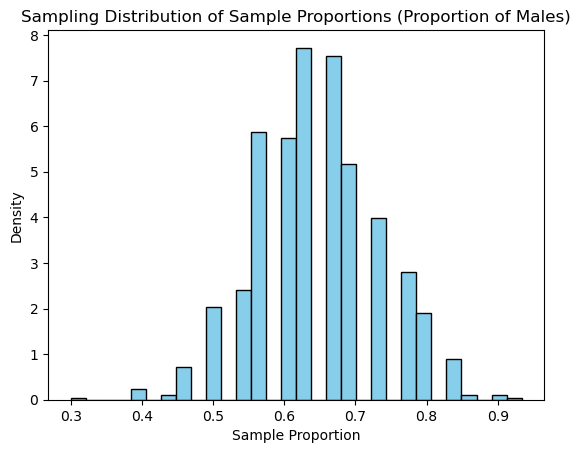

In [3]:
# Step 2: Generate Sample Proportions
import matplotlib.pyplot as plt

# Parameters
population = tips['sex'] == 'Male'  # Convert to binary: True = Male, False = Female
n_samples = 1000  # Number of samples
sample_size = 30  # Size of each sample

# Collect sample proportions
sample_proportions = [
    np.mean(np.random.choice(population, size=sample_size, replace=True)) for _ in range(n_samples)
]

# Plot the sampling distribution
plt.hist(sample_proportions, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Sampling Distribution of Sample Proportions (Proportion of Males)')
plt.xlabel('Sample Proportion')
plt.ylabel('Density')
plt.show()

**Step 3: Compare with the Theoretical Normal Distribution**
Theoretical mean and standard error:
$$
\mu_{\hat{p}} = p = 0.644, \quad \sigma_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}} = \sqrt{\frac{0.644 \cdot 0.356}{30}} \approx 0.085
$$

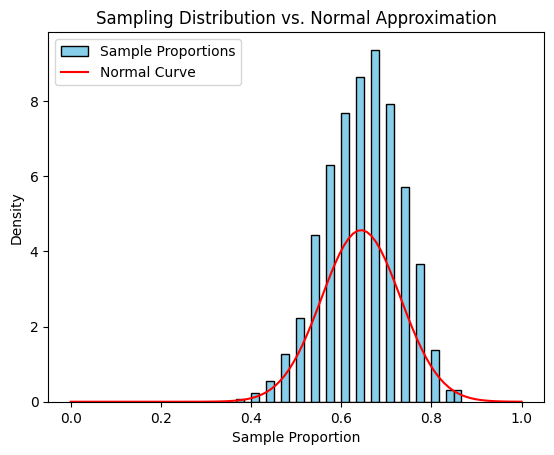

In [ ]:
from scipy.stats import norm

# Theoretical parameters
mean = 0.644
std_error = np.sqrt((mean * (1 - mean)) / sample_size)

# Plot the histogram and normal curve
x = np.linspace(0, 1, 100)
normal_curve = norm.pdf(x, mean, std_error)

plt.hist(sample_proportions, bins=30, density=True, color='skyblue', edgecolor='black', label='Sample Proportions')
plt.plot(x, normal_curve, color='red', label='Normal Curve')
plt.title('Sampling Distribution vs. Normal Approximation')
plt.xlabel('Sample Proportion')
plt.ylabel('Density')
plt.legend()
plt.show()

**4. Observations**
1. The histogram of sample proportions becomes bell-shaped and closely resembles the theoretical normal curve as the number of samples increases.
2. The mean of the sampling distribution aligns closely with the true proportion p = 0.644.
3. The spread of the distribution matches the calculated standard error $\sigma_{\hat{p}}$.
4. The key takeaway is that regardless of the original population distribution, the sampling distribution of sample proportions approaches a normal distribution when the sample size is sufficiently large.